# Week 2 – Supervised Machine Learning Models

## Iris Species Classification

This project focuses on building and evaluating supervised machine learning
classification models using the Iris dataset.

In [1]:
# Import the required libraries
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

import matplotlib.pyplot as plt

# Load the Dataset

The Iris dataset is loaded using Pandas and inspected to understand its structure and dimensions.

In [2]:
df = pd.read_csv("iris_dataset.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully!
Shape: (150, 5)


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


# Explore the Dataset

Before building machine learning models, the dataset is inspected to understand its columns, data types, statistical information, and target categories.

In [3]:
print("Column names:")
print(df.columns)

print("\nDataset information:")
df.info()

print("\nStatistical summary:")
print(df.describe())

print("\nSpecies categories:")
print(df["species"].unique())

print("\nSpecies counts:")
print(df["species"].value_counts())

Column names:
Index(['sepal_length', 'sepal_width', 'petal_length', 'petal_width',
       'species'],
      dtype='str')

Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    str    
dtypes: float64(4), str(1)
memory usage: 6.0 KB

Statistical summary:
       sepal_length  sepal_width  petal_length  petal_width
count    150.000000   150.000000    150.000000   150.000000
mean       5.843333     3.057333      3.758000     1.199333
std        0.828066     0.435866      1.765298     0.762238
min        4.300000     2.000000      1.000000     0.100000
25%        5.100000     2.800000      1.600000     0.300000
50%        5.800000     3.000000 

# Select Features and Target

The four numerical measurements are used as input features.

The 'species' column is used as the target variable that the machine learning models will learn to predict.

In [4]:
features = [
    "sepal_length",
    "sepal_width",
    "petal_length",
    "petal_width"
]

X = df[features]
y = df["species"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

print("\nFeatures:")
print(X.head())

print("\nTarget:")
print(y.head())

Features shape: (150, 4)
Target shape: (150,)

Features:
   sepal_length  sepal_width  petal_length  petal_width
0           5.1          3.5           1.4          0.2
1           4.9          3.0           1.4          0.2
2           4.7          3.2           1.3          0.2
3           4.6          3.1           1.5          0.2
4           5.0          3.6           1.4          0.2

Target:
0    setosa
1    setosa
2    setosa
3    setosa
4    setosa
Name: species, dtype: str


# Encode the Target Variable

Machine learning algorithms require numerical target values.

The categorical species labels are converted into numerical values using
Label Encoding:

- Setosa → 0
- Versicolor → 1
- Virginica → 2

In [5]:
label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)

print("Encoded target values:")
print(y_encoded[:10])

print("\nSpecies mapping:")

for species, value in zip(
    label_encoder.classes_,
    label_encoder.transform(label_encoder.classes_)
):
    print(species, "→", value)

Encoded target values:
[0 0 0 0 0 0 0 0 0 0]

Species mapping:
setosa → 0
versicolor → 1
virginica → 2


# Split the Dataset into Training and Testing Sets

The dataset is divided into training and testing data.

- 80% of the data is used for training.
- 20% of the data is used for testing.

The training data is used to build the models, while the testing data is used to evaluate how well the models perform on unseen data.

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.20,
    random_state=42,
    stratify=y_encoded
)

print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)
print("Training target:", y_train.shape)
print("Testing target:", y_test.shape)

Training features: (120, 4)
Testing features: (30, 4)
Training target: (120,)
Testing target: (30,)


# Logistic Regression

Logistic Regression is a supervised machine learning classification algorithm.

In this project, it is used to classify an iris flower into one of the three species: Setosa, Versicolor, or Virginica.

In [7]:
logistic_model = LogisticRegression(max_iter=200)

logistic_model.fit(X_train, y_train)

logistic_predictions = logistic_model.predict(X_test)

logistic_accuracy = accuracy_score(
    y_test,
    logistic_predictions
)

print("Logistic Regression Accuracy:",
      logistic_accuracy)

Logistic Regression Accuracy: 0.9666666666666667


# Decision Tree Classifier

A Decision Tree is a supervised classification algorithm that makes decisions
using a sequence of rules based on feature values.

The model learns these rules from the training data and uses them to predict
the species of unseen iris flowers.

In [8]:
decision_tree_model = DecisionTreeClassifier(
    random_state=42
)

decision_tree_model.fit(X_train, y_train)

decision_tree_predictions = decision_tree_model.predict(X_test)

decision_tree_accuracy = accuracy_score(
    y_test,
    decision_tree_predictions
)

print("Decision Tree Accuracy:",
      decision_tree_accuracy)

Decision Tree Accuracy: 0.9333333333333333


# Random Forest Classifier

Random Forest is an ensemble machine learning algorithm that combines multipleDecision Trees.

Each tree produces a prediction, and the Random Forest combines the results to make the final classification.

In [9]:
random_forest_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

random_forest_model.fit(X_train, y_train)

random_forest_predictions = random_forest_model.predict(X_test)

random_forest_accuracy = accuracy_score(
    y_test,
    random_forest_predictions
)

print("Random Forest Accuracy:",
      random_forest_accuracy)

Random Forest Accuracy: 0.9


# K-Nearest Neighbors (KNN)

K-Nearest Neighbors is a supervised classification algorithm that predicts
the class of a new observation based on the classes of its nearest neighbors.

In this project, KNN is configured to use 5 nearest neighbors.

In [10]:
knn_model = KNeighborsClassifier(
    n_neighbors=5
)

knn_model.fit(X_train, y_train)

knn_predictions = knn_model.predict(X_test)

knn_accuracy = accuracy_score(
    y_test,
    knn_predictions
)

print("KNN Accuracy:",
      knn_accuracy)

KNN Accuracy: 1.0


# Compare Model Performance

The four classification models are compared using their test-set accuracy.

The models evaluated are:

- Logistic Regression
- Decision Tree
- Random Forest
- K-Nearest Neighbors

In [11]:
model_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "KNN"
    ],
    "Accuracy": [
        logistic_accuracy,
        decision_tree_accuracy,
        random_forest_accuracy,
        knn_accuracy
    ]
})

print(model_results)

                 Model  Accuracy
0  Logistic Regression  0.966667
1        Decision Tree  0.933333
2        Random Forest  0.900000
3                  KNN  1.000000


# Accuracy Comparison

A bar chart is created to visually compare the accuracy achieved by each machine learning model.

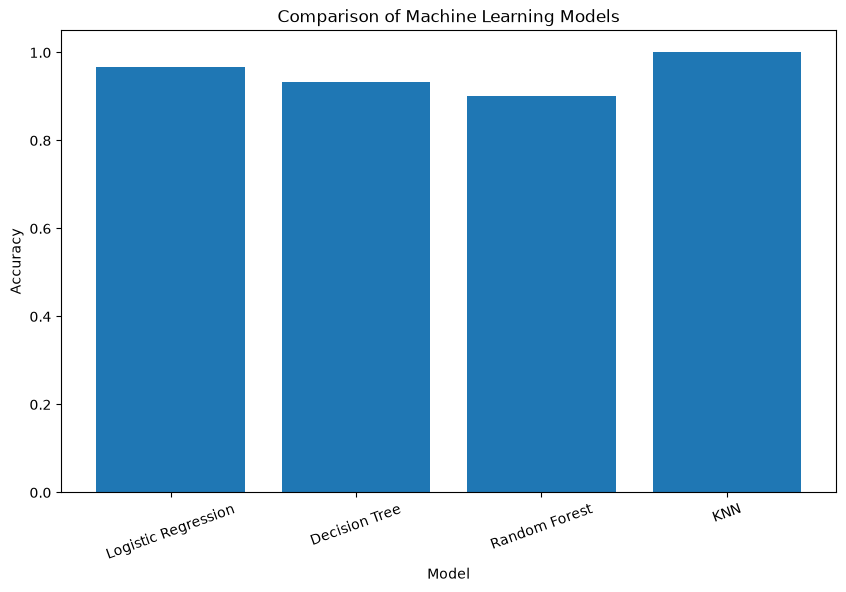

In [12]:
plt.figure(figsize=(10, 6))

plt.bar(
    model_results["Model"],
    model_results["Accuracy"]
)

plt.title("Comparison of Machine Learning Models")
plt.xlabel("Model")
plt.ylabel("Accuracy")

plt.xticks(rotation=20)
plt.ylim(0, 1.05)

plt.show()

# Classification Reports

Accuracy provides an overall measure of correct predictions.

Classification reports provide additional evaluation metrics:

- Precision
- Recall
- F1-score
- Support

These metrics are calculated for each Iris species.

In [13]:
print("Logistic Regression Classification Report")
print(
    classification_report(
        y_test,
        logistic_predictions,
        target_names=label_encoder.classes_
    )
)

print("\nDecision Tree Classification Report")
print(
    classification_report(
        y_test,
        decision_tree_predictions,
        target_names=label_encoder.classes_
    )
)

print("\nRandom Forest Classification Report")
print(
    classification_report(
        y_test,
        random_forest_predictions,
        target_names=label_encoder.classes_
    )
)

print("\nKNN Classification Report")
print(
    classification_report(
        y_test,
        knn_predictions,
        target_names=label_encoder.classes_
    )
)

Logistic Regression Classification Report
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30


Decision Tree Classification Report
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30


Random Forest Classification Report
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor 

# Confusion Matrices

A confusion matrix shows the number of correctly and incorrectly classified samples for each Iris species.

In [14]:
models_predictions = {
    "Logistic Regression": logistic_predictions,
    "Decision Tree": decision_tree_predictions,
    "Random Forest": random_forest_predictions,
    "KNN": knn_predictions
}

for model_name, predictions in models_predictions.items():

    cm = confusion_matrix(
        y_test,
        predictions
    )

    print("\n" + model_name)
    print(cm)


Logistic Regression
[[10  0  0]
 [ 0  9  1]
 [ 0  0 10]]

Decision Tree
[[10  0  0]
 [ 0  9  1]
 [ 0  1  9]]

Random Forest
[[10  0  0]
 [ 0  9  1]
 [ 0  2  8]]

KNN
[[10  0  0]
 [ 0 10  0]
 [ 0  0 10]]


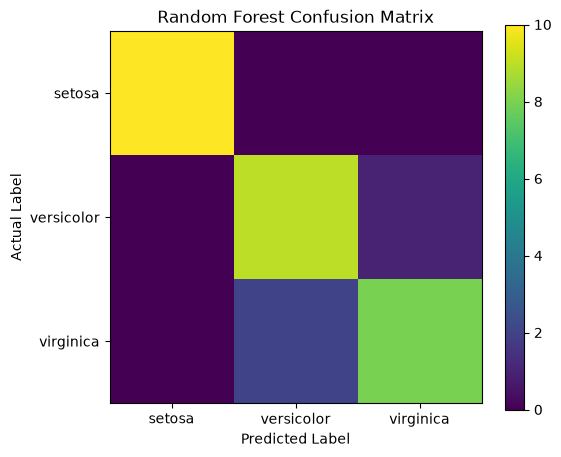

In [15]:
cm = confusion_matrix(
    y_test,
    random_forest_predictions
)

plt.figure(figsize=(6, 5))

plt.imshow(cm)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.xticks(
    range(3),
    label_encoder.classes_
)

plt.yticks(
    range(3),
    label_encoder.classes_
)

plt.colorbar()

plt.show()

# Linear Regression

Linear Regression is a supervised machine learning algorithm used to predict continuous numerical values.

Since the Iris `species` column is categorical, Linear Regression is not suitable for predicting species.

Therefore, a separate regression task is performed by predicting `petal_length` using the other numerical features.

In [16]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Select features for regression
regression_features = [
    "sepal_length",
    "sepal_width",
    "petal_width"
]

X_reg = df[regression_features]
y_reg = df["petal_length"]

# Split regression data
X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg,
    y_reg,
    test_size=0.20,
    random_state=42
)

print("Regression training features:", X_reg_train.shape)
print("Regression testing features:", X_reg_test.shape)

Regression training features: (120, 3)
Regression testing features: (30, 3)


In [17]:
linear_regression_model = LinearRegression()

linear_regression_model.fit(
    X_reg_train,
    y_reg_train
)

linear_regression_predictions = linear_regression_model.predict(
    X_reg_test
)

print("Linear Regression model trained successfully.")

Linear Regression model trained successfully.


# Evaluate Linear Regression

The Linear Regression model is evaluated using:

- Mean Absolute Error (MAE)
- Mean Squared Error (MSE)
- R² Score

These metrics help measure how accurately the model predicts the continuous `petal_length` values.

In [18]:
linear_mae = mean_absolute_error(
    y_reg_test,
    linear_regression_predictions
)

linear_mse = mean_squared_error(
    y_reg_test,
    linear_regression_predictions
)

linear_r2 = r2_score(
    y_reg_test,
    linear_regression_predictions
)

print("Linear Regression Evaluation")
print("----------------------------")
print("Mean Absolute Error:", linear_mae)
print("Mean Squared Error:", linear_mse)
print("R² Score:", linear_r2)

Linear Regression Evaluation
----------------------------
Mean Absolute Error: 0.26051798462523856
Mean Squared Error: 0.13001626031382682
R² Score: 0.9603293155857664


# Actual vs Predicted Values

The actual and predicted `petal_length` values are compared to understand the performance of the Linear Regression model.

In [19]:
regression_results = pd.DataFrame({
    "Actual Petal Length": y_reg_test.values,
    "Predicted Petal Length": linear_regression_predictions
})

print(regression_results)

    Actual Petal Length  Predicted Petal Length
0                   4.7                4.127716
1                   1.7                1.882002
2                   6.9                7.025659
3                   4.5                4.432110
4                   4.8                4.927191
5                   1.5                2.066237
6                   3.6                3.849479
7                   5.1                6.129499
8                   4.5                5.021745
9                   3.9                3.974453
10                  5.1                5.336534
11                  1.4                1.446617
12                  1.3                1.781432
13                  1.5                1.455317
14                  1.5                1.448313
15                  4.7                4.541380
16                  5.8                5.757203
17                  3.9                3.810301
18                  4.5                3.985343
19                  5.6                5

# Linear Regression Visualization

A scatter plot is created to compare the actual petal length values with the predicted values from the Linear Regression model.

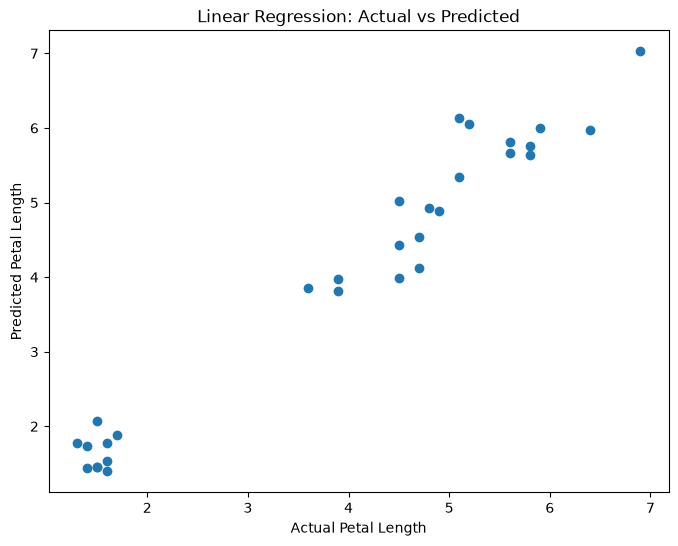

In [20]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_reg_test,
    linear_regression_predictions
)

plt.xlabel("Actual Petal Length")
plt.ylabel("Predicted Petal Length")
plt.title("Linear Regression: Actual vs Predicted")

plt.show()

In [21]:
model_results.to_csv(
    "model_comparison_results.csv",
    index=False
)

print("Model comparison results saved successfully.")

Model comparison results saved successfully.
